In [493]:
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import os

In [494]:
ORIGINAL_FPS = 30
MANUAL_FPSS = ['3', '5', '10', '15', '30']
USE_MANUAL_FPSS = True
THRESHOLD = 0.75

In [495]:
interval = 1

In [496]:
RP_AMOUNT = 16

In [497]:
accuracy_result_dict_paths = [
	'./short_result/plot_set/Scene-1-Day_Accuracy_Result.json',
	'./short_result/plot_set/Scene-1-Afternoon_Accuracy_Result.json',
	'./short_result/plot_set/Scene-1-Night_Accuracy_Result.json',
	# './short_result/plot_set/Scene-1-Midnight_Accuracy_Result.json',
]

In [498]:
movement_result_dict_paths = [
	'./short_result/plot_set/Scene-1-Day_Movement_Result.json',
	'./short_result/plot_set/Scene-1-Afternoon_Movement_Result.json',
	'./short_result/plot_set/Scene-1-Night_Movement_Result.json',
	# './short_result/plot_set/Scene-1-Midnight_Movement_Result.json',
]

In [499]:
colors = [
	# '#e6194B',
	'#f58231',
	'#9A6324',
	'#911eb4',
	'#3cb44b',
	'#f032e6',
	'#4363d8',
	'#f7cc1d',
]

In [500]:
def load_json(filepath):
	with open(filepath, 'r') as file:
		data = json.load(file)
		
	return data

In [501]:
def extract_fpss(metric_list, data_type='metric'):
	return list(metric_list[list(metric_list.keys())[0]][0][data_type].keys())

In [502]:
def extract_metric_list(metric_list, fpss, feature='F1', data_type='metric'):
	result_column = {}
		
	for fps in fpss:
		if data_type == 'metric':
			result_column[fps] = [clip_metric[data_type][fps][feature] for clip_metric in metric_list]
		elif data_type == 'movement':
			result_column[fps] = [clip_metric[data_type][fps] for clip_metric in metric_list]
		
	return result_column

In [503]:
def cumulative_sum_list(input_list):
	result = []
	total = 0
	for item in input_list:
		total += item
		result.append(total)
	return result

def extract_metric_time(metric_list):
	frame_number_list = [clip_metric['frame_count'] for clip_metric in metric_list]
	time_list = cumulative_sum_list(frame_number_list)
	time_list = list(np.array(time_list) - time_list[0])
	scaled_time_list = list(np.array(time_list) / ORIGINAL_FPS)

	return round_floats_to_sigfigs(scaled_time_list, 0)

In [504]:
def combine_times(matrix, interval):
		result = []
		new_len = math.floor(len(matrix) / interval)

		for i in range(new_len):
				result.append(np.average(np.array(matrix[i:i+interval])))
		
		return result

In [505]:
def plot_two_ys(xs, y1s, y2s, x_label, y1_label, y2_label, title, label_size=28, font_size=32):
	fig, ax1 = plt.subplots(figsize=(36, 9))

	ax1.plot(xs, y1s, color='skyblue', marker='o', label=y1_label)  # 'o' denotes the marker type
	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y1_label, color='skyblue', fontsize=font_size)
	ax1.tick_params(axis='both', labelsize=label_size)
	ax1.set_xlim([0, 180])

	ax2 = ax1.twinx()
	ax2.plot(xs, y2s, color='orange', marker='o', label=y2_label)  # 'o' denotes the marker type
	ax2.set_ylabel(y2_label, color='orange', fontsize=font_size)
	ax2.tick_params(axis='y', labelsize=label_size)
	ax2.set_xlim([0, 180])

	plt.title(title, fontsize=font_size)
	plt.grid(True)

	plt.show()

In [506]:
def plot_mutiple_lines(xs, yss, x_label, y_label, y_legends, title, fig_size, label_size=28, font_size=32, legend_size=20):
	fig, ax1 = plt.subplots(figsize=fig_size)

	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], label=y_legends[i])

	ax1.set_xlim([0, 180])
	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [507]:
def dict_feature_idx(d, feature_idx):
	result_dict = {}
	for k in d.keys():
		result_dict[k] = [cf[feature_idx] for cf in d[k]]
	
	return result_dict

In [508]:
def average_of_lists_in_dict(data):
		"""
		Computes the average of corresponding elements across all lists in a dictionary.
		
		Args:
				data (dict): A dictionary where values are lists of the same length.
		
		Returns:
				list: A list of averages, with each element corresponding to the average of
							the respective index across all lists in the dictionary.
		"""
		# Ensure the dictionary is not empty
		if not data:
				return []

		# Extract the lists from the dictionary values
		lists = list(data.values())

		# Check that all lists have the same length
		if not all(len(lst) == len(lists[0]) for lst in lists):
				raise ValueError("All lists in the dictionary must be of the same length.")

		# Calculate the average for each index
		num_lists = len(lists)
		result = [
				sum(values) / num_lists
				for values in zip(*lists)
		]

		return result

In [509]:
def calculate_slope(float_list):
    """
    Calculates the slope between consecutive points in a float list.
    Assumes equally spaced x-values.
    
    Parameters:
        float_list (list of float): The input list of floats.
    
    Returns:
        list of float: A list of slopes between consecutive points.
    """
    if len(float_list) < 2:
        raise ValueError("The list must contain at least two elements to calculate slopes.")
    
    slopes = []
    for i in range(len(float_list) - 1):
        slope = (float_list[i + 1] - float_list[i])
        slopes.append(slope)
    
    return slopes

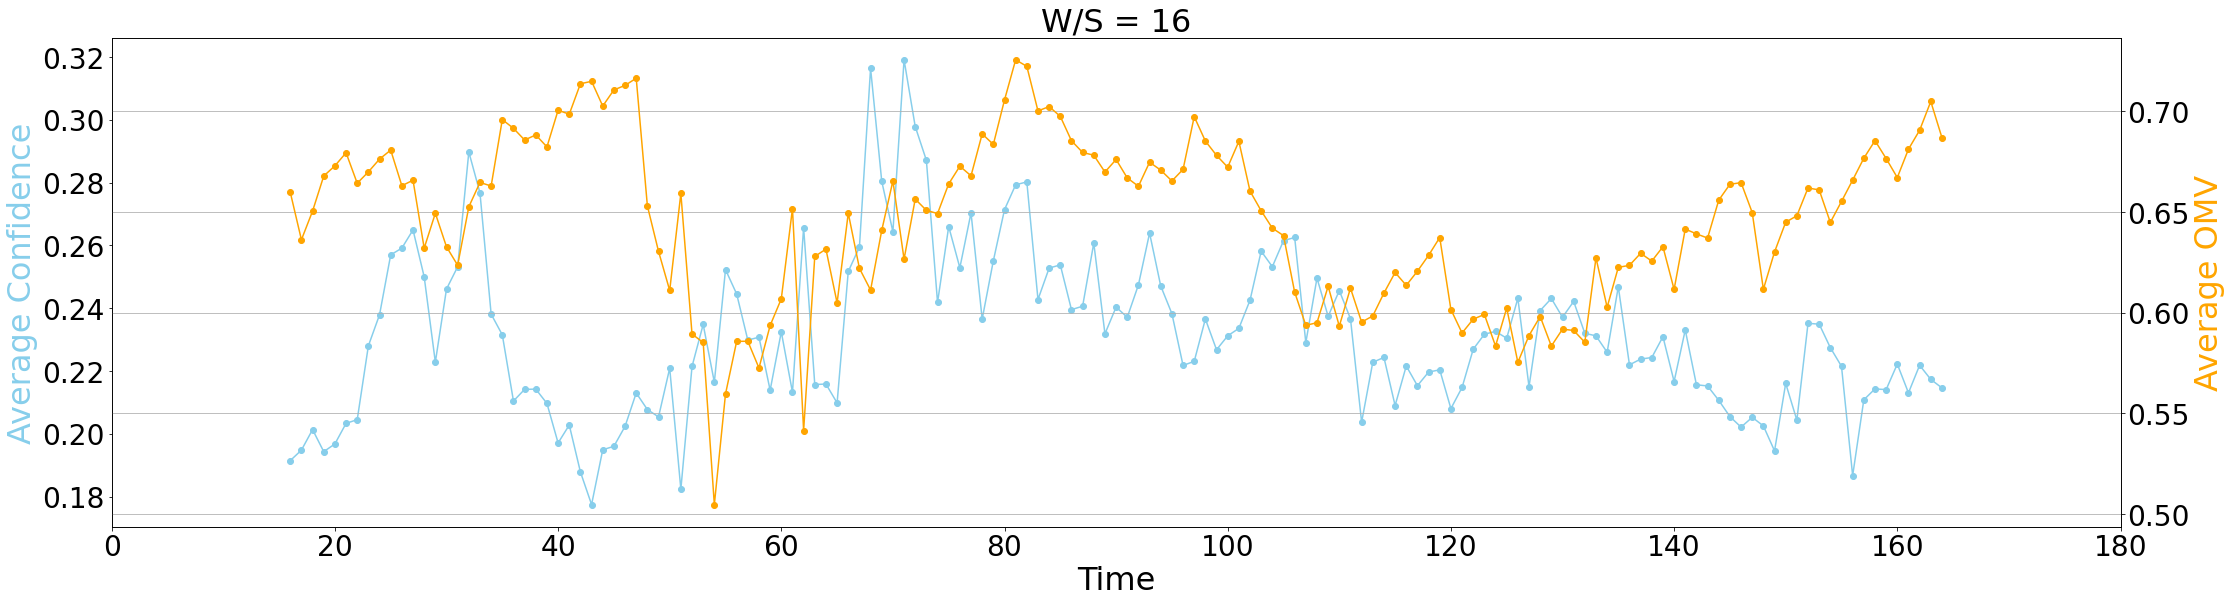

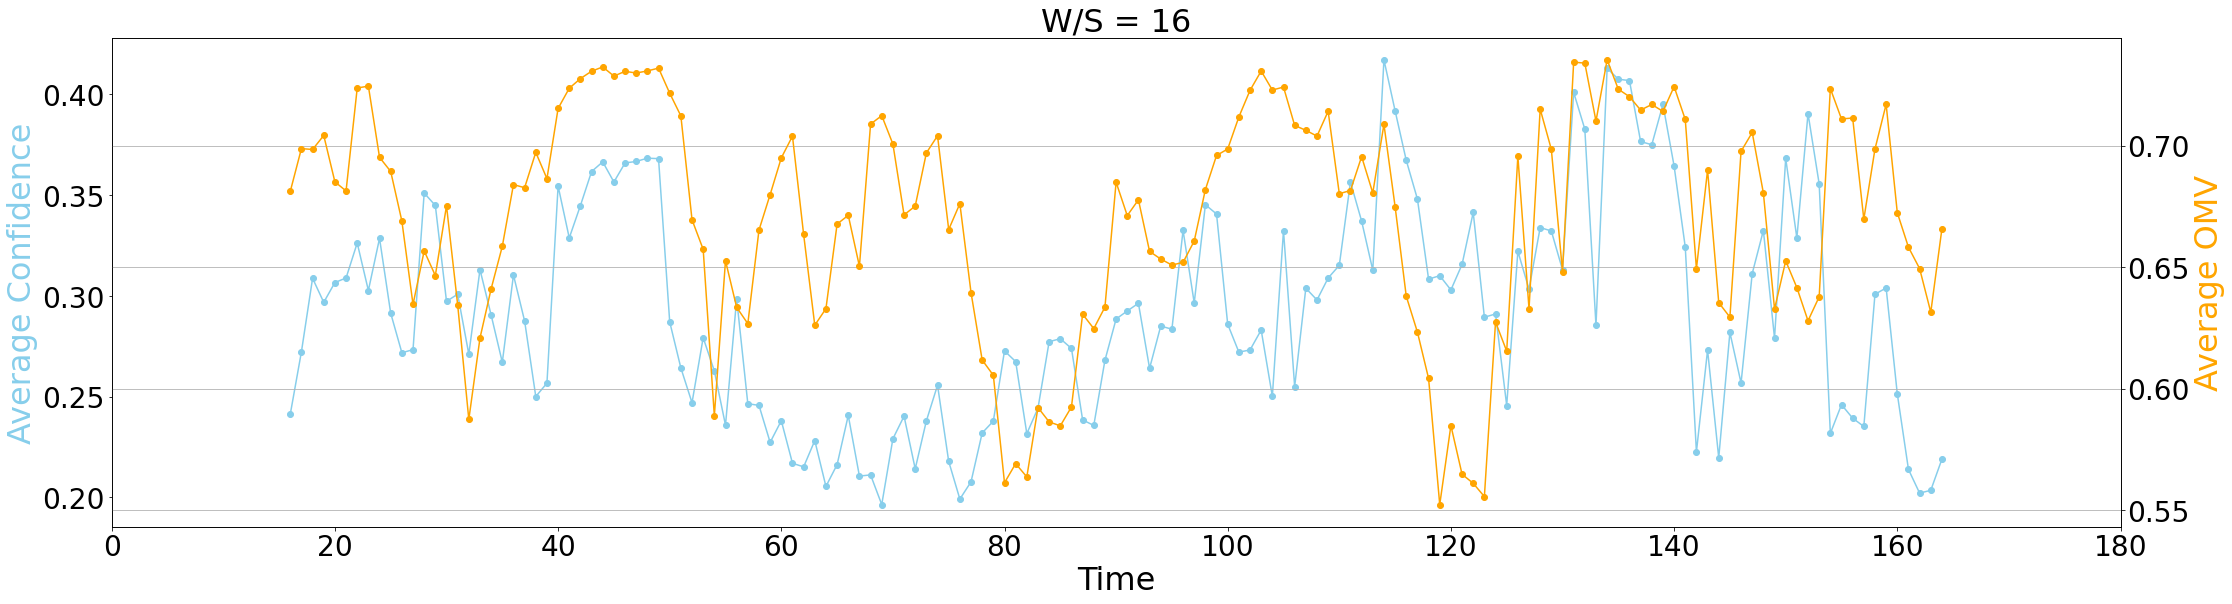

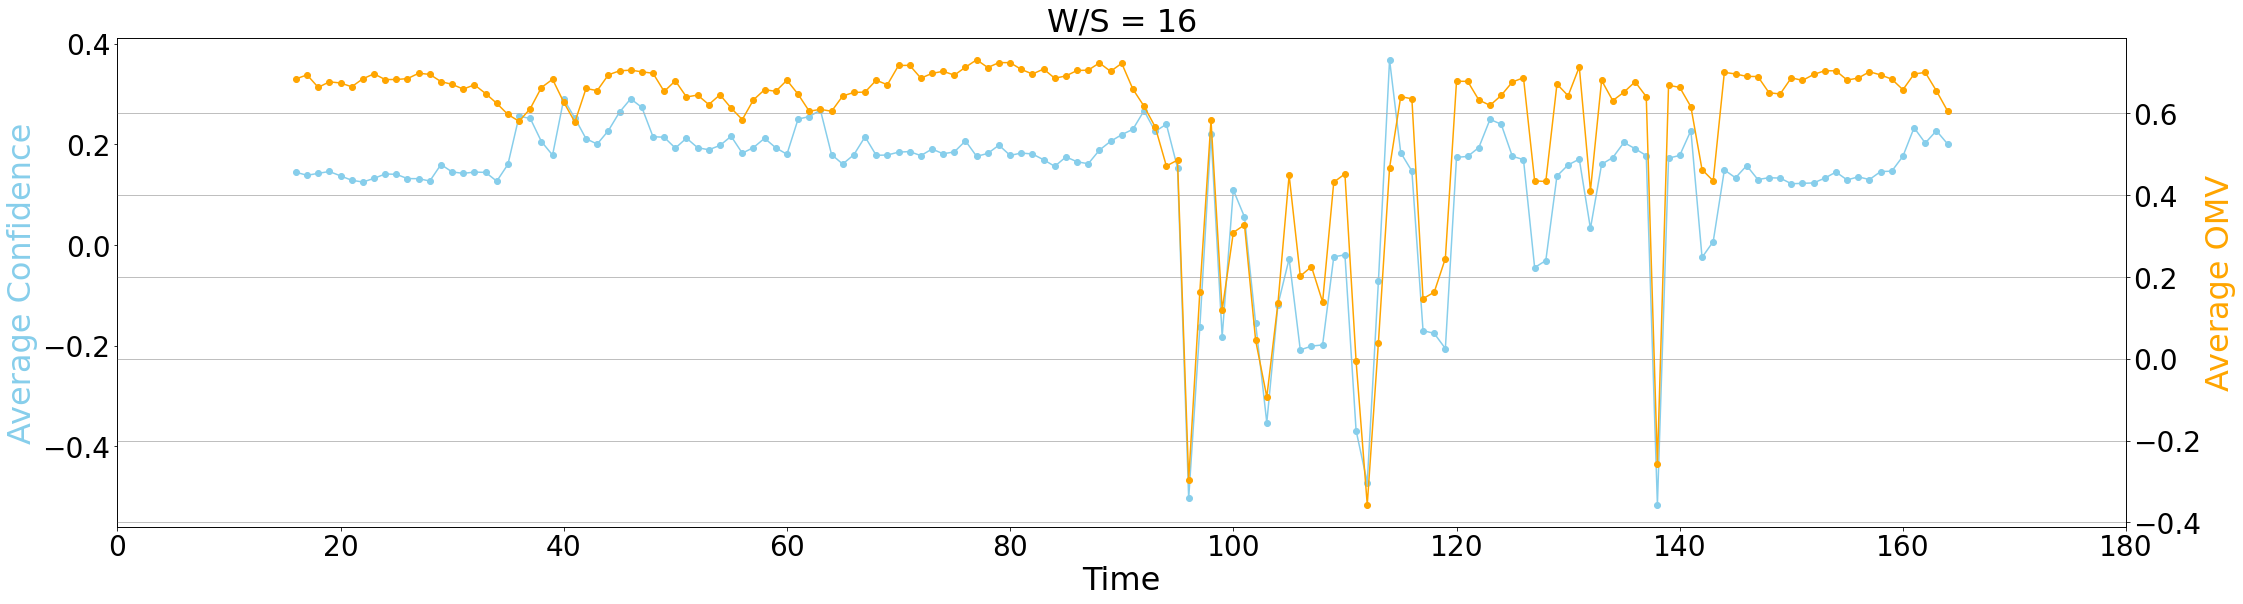

In [510]:
profiling_result = {}

for i in range(len(accuracy_result_dict_paths)):
	video_prefix = f'{os.path.splitext(os.path.basename(accuracy_result_dict_paths[i]))[0]}'
	video_prefix = video_prefix[0 : video_prefix.find('_')]
	profiling_result[video_prefix] = {}
	accuracy_result_dict_path = accuracy_result_dict_paths[i]
	accuracy_result_dict = load_json(accuracy_result_dict_path)
	
	fpss = extract_fpss(accuracy_result_dict)

	movement_result_dict_path = movement_result_dict_paths[i]
	movement_result_dict = load_json(movement_result_dict_path)

	for class_idx in list(accuracy_result_dict.keys()):
		accuracy_result = extract_metric_list(accuracy_result_dict[class_idx], fpss)
		movement_result = extract_metric_list(movement_result_dict[class_idx], fpss, data_type='movement')
		movement_result_feature_idx_con = dict_feature_idx(movement_result, 5) # Confidence
		movement_result_feature_idx_omv = dict_feature_idx(movement_result, 6) # OMV
		

		avg_con_result = average_of_lists_in_dict(movement_result_feature_idx_con)
		avg_omv_result = average_of_lists_in_dict(movement_result_feature_idx_omv)

		combined_con = combine_times(avg_con_result, interval)
		combined_omv = combine_times(avg_omv_result, interval)
		time = list(np.array(range(len(combined_con))) * interval)
		
		plot_s = RP_AMOUNT
		plot_e = len(time)-RP_AMOUNT+1
		plot_two_ys(time[plot_s : plot_e], combined_con[plot_s : plot_e], combined_omv[plot_s : plot_e], 'Time', 'Average Confidence', 'Average OMV', f'W/S = {RP_AMOUNT}')

		profiling_result[video_prefix]['combined_con'] = combined_con
		profiling_result[video_prefix]['combined_omv'] = combined_omv


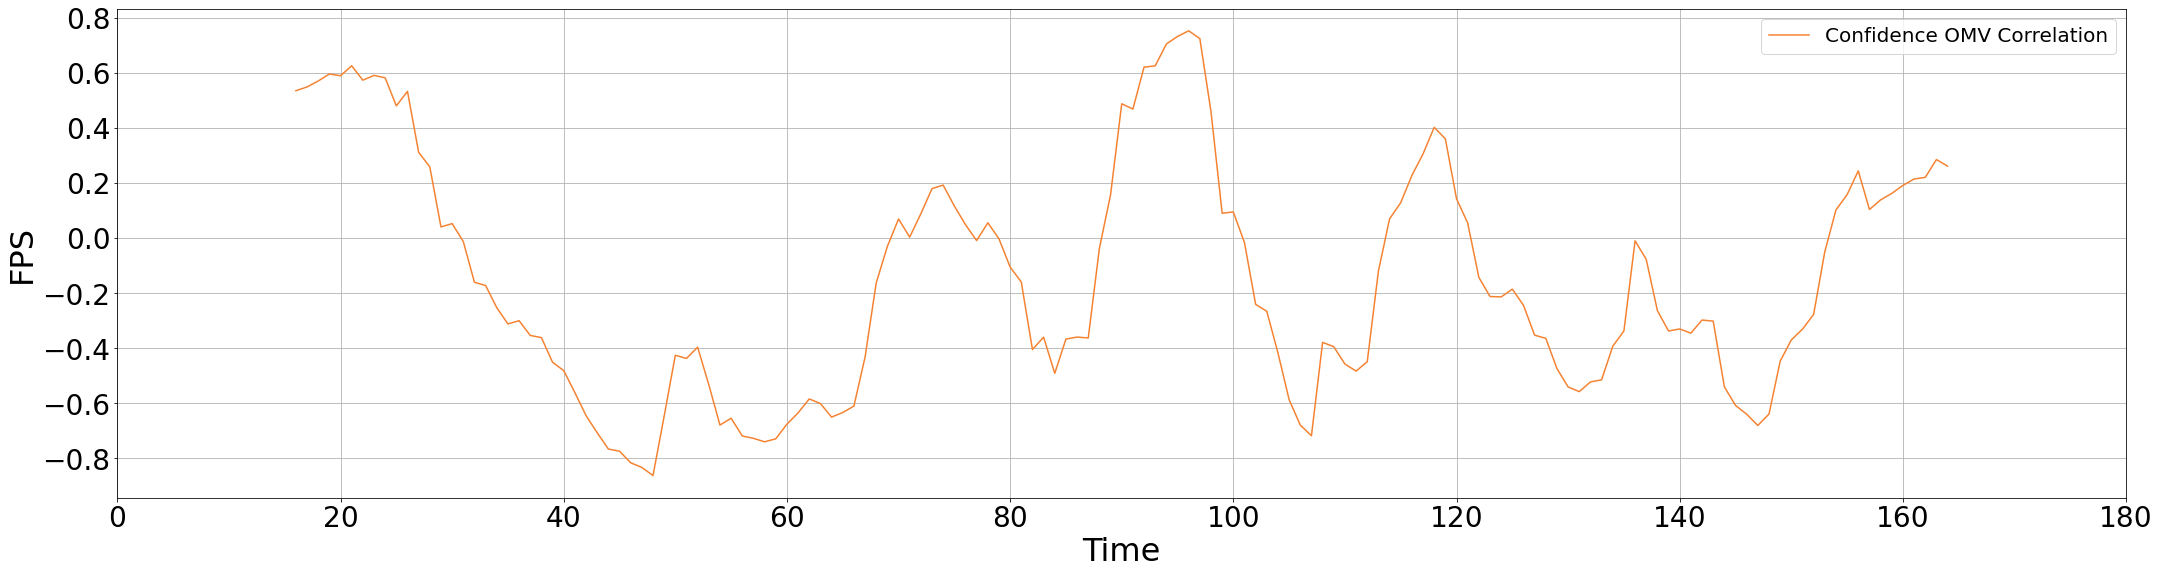

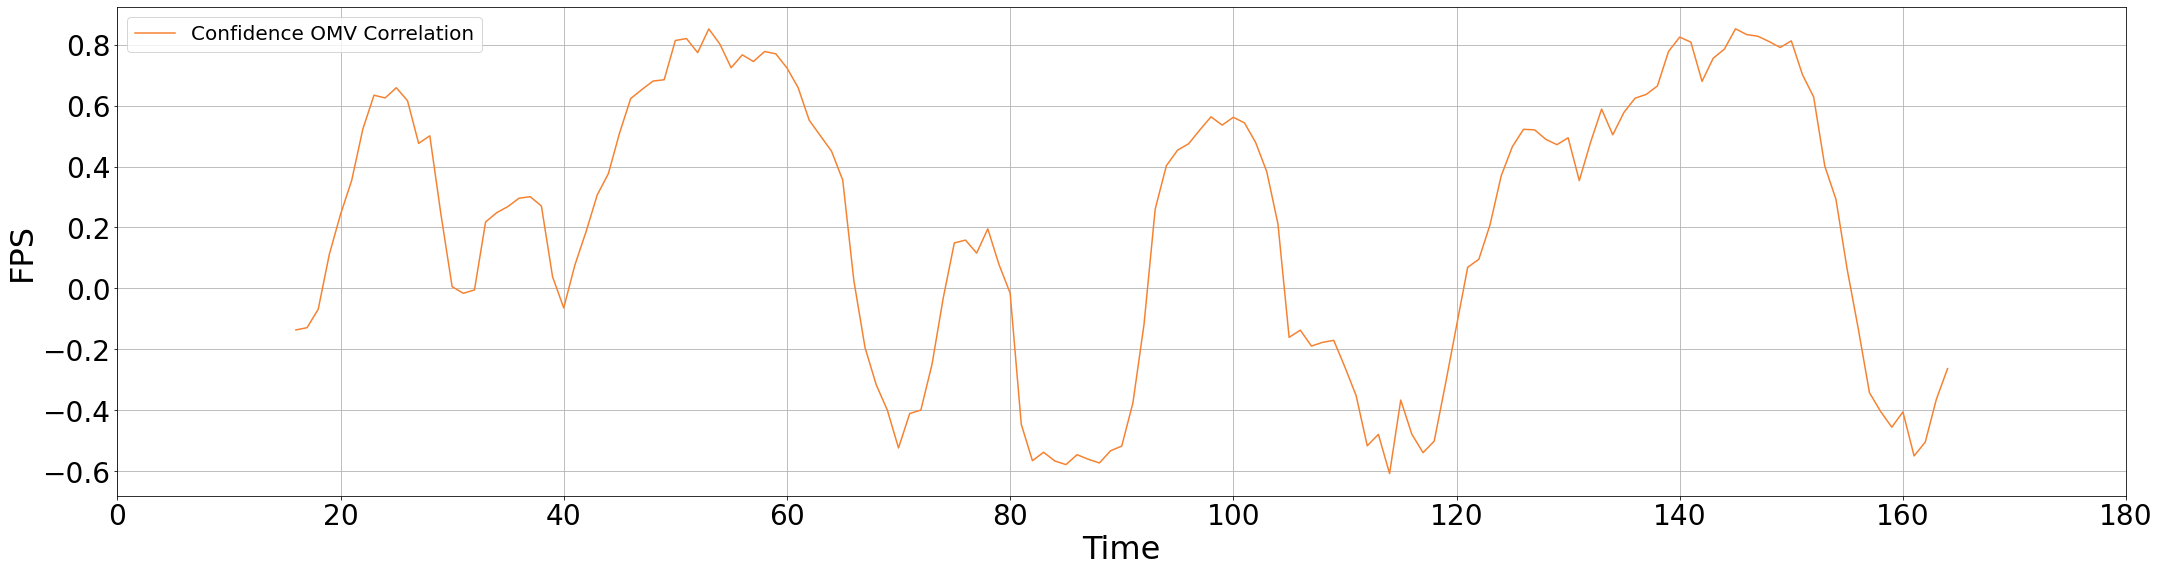

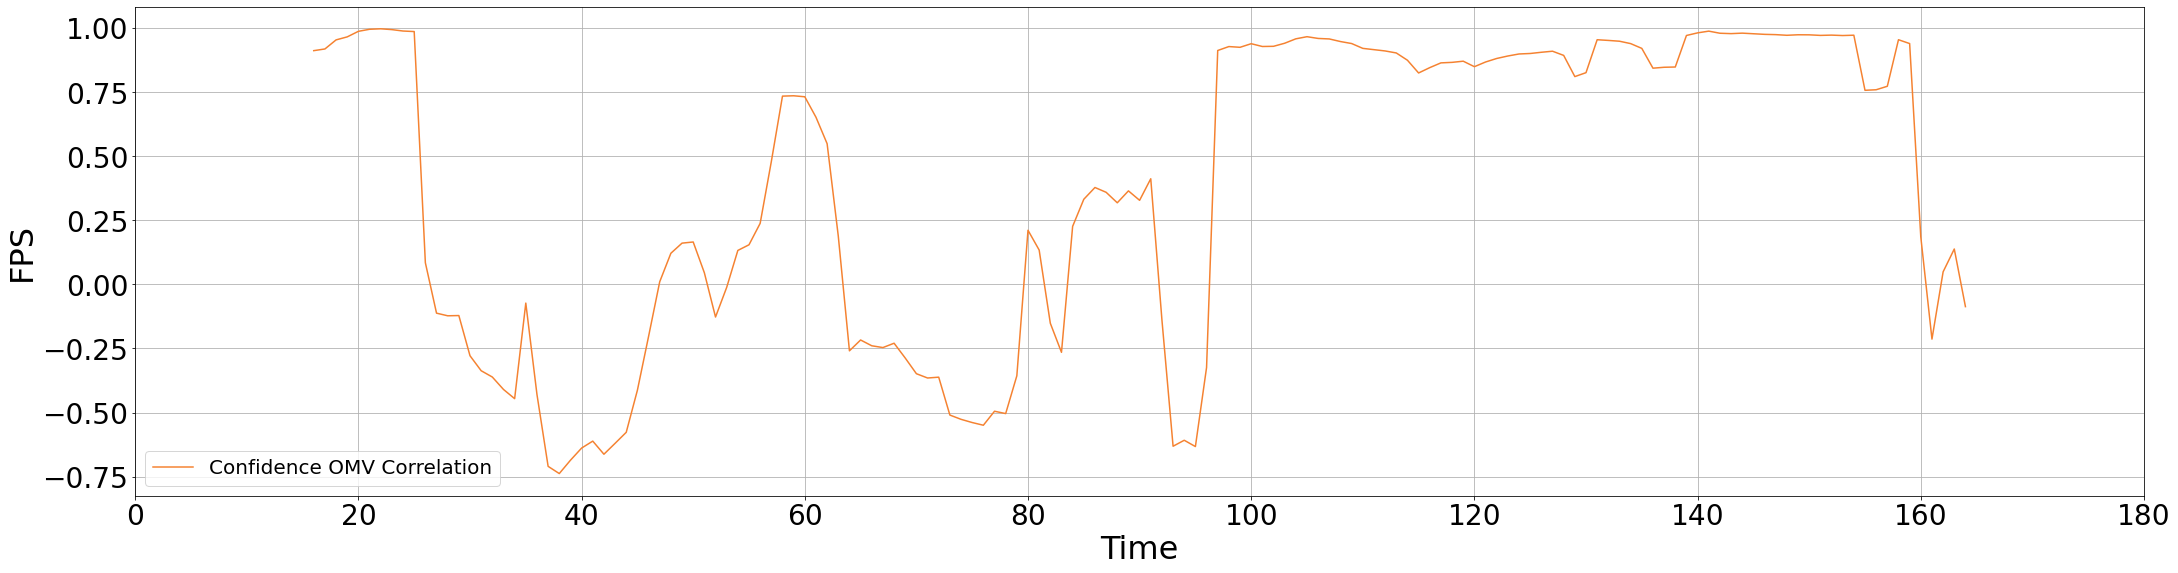

In [511]:
for i in range(len(accuracy_result_dict_paths)):
	video_prefix = f'{os.path.splitext(os.path.basename(accuracy_result_dict_paths[i]))[0]}'
	video_prefix = video_prefix[0 : video_prefix.find('_')]
	con_list = profiling_result[video_prefix]['combined_con']
	omv_list = profiling_result[video_prefix]['combined_omv']
	test_length = len(con_list)

	con_omv_corr_list = []
	for i in range(RP_AMOUNT, test_length-RP_AMOUNT+1):
		correlation_matrix = np.corrcoef(con_list[i-RP_AMOUNT : i], omv_list[i-RP_AMOUNT : i])
		correlation = correlation_matrix[0, 1]
		con_omv_corr_list.append(correlation)

	time = list(range(RP_AMOUNT, test_length-RP_AMOUNT+1))
	plot_mutiple_lines(time, [con_omv_corr_list], 'Time', 'FPS', ['Confidence OMV Correlation'], '', (36, 9))
